# GDEX Download Workflow

---

## Overview

This notebook demonstrates how to directly access a NetCDF file on GDEX over HTTPS with fsspec and run analysis on it, without downloading the file to disk.

1. Find a file's HTTPS URL
2. Open it lazily with fsspec
3. Load it with xarray and run analysis

## Prerequisites

| Concepts | Importance | Notes |
| --- | --- | --- |
| download_intro | Necessary | File listing and HTTP download |
| [fsspec](https://filesystem-spec.readthedocs.io) | Necessary | Remote file access |
| [xarray](https://xarray.pydata.org) | Necessary | |

- **Time to learn**: 15 minutes

---

## Imports

In [1]:
import matplotlib.pyplot as plt
import fsspec
import xarray as xr

## Step 1 — Find a File’s HTTPS URL

From the GDEX web portal, we can identify the direct HTTPS link to the NetCDF file:

`https://osdf-director.osg-htc.org/ncar/gdex/d651056/CESM2-LE/atm/proc/tseries/month_1/LHFLX/b.e21.BHISTcmip6.f09_g17.LE2-1001.001.cam.h0.LHFLX.185001-185912.nc`

Opening this URL in a browser typically starts a file download.  
In this workflow, we instead use the URL programmatically so the data can be accessed directly in memory (via `fsspec`/`xarray`) without first saving a local copy.

:::{figure} ../../images/gdex-web-url.png
:alt: GDEX data file URL page
:width: 90%

The direct file URL can be copied from the GDEX data access page.
:::


## Step 2 — Open the File Lazily with fsspec

`fsspec`'s HTTP filesystem opens a remote file as a Python file-like object backed by HTTP range requests, so only the bytes you access are transferred.

In [ ]:
# open the remote NetCDF file
file_url = 'https://osdf-director.osg-htc.org/ncar/gdex/d651056/CESM2-LE/atm/proc/tseries/month_1/LHFLX/b.e21.BHISTcmip6.f09_g17.LE2-1001.001.cam.h0.LHFLX.185001-185912.nc'

fs = fsspec.filesystem("http")
remote_file = fs.open(file_url)
ds = xr.open_dataset(remote_file)

## Step 3 — Load with xarray and Plot

Call `.load()` on a variable to fetch its data into memory, then visualize it with matplotlib.

In [3]:
ds['co2vmr'].load()

<xarray.DataArray 'co2vmr' (time: 120)> Size: 960B
array([0.00028427, 0.00028428, 0.00028429, 0.0002843 , 0.00028431,
       0.00028432, 0.00028433, 0.00028434, 0.00028435, 0.00028436,
       0.00028437, 0.00028438, 0.0002844 , 0.00028441, 0.00028442,
       0.00028443, 0.00028444, 0.00028445, 0.00028446, 0.00028448,
       0.00028449, 0.0002845 , 0.00028451, 0.00028452, 0.00028454,
       0.00028455, 0.00028456, 0.00028457, 0.00028459, 0.0002846 ,
       0.00028461, 0.00028462, 0.00028463, 0.00028464, 0.00028465,
       0.00028466, 0.00028468, 0.00028469, 0.0002847 , 0.00028471,
       0.00028472, 0.00028473, 0.00028474, 0.00028475, 0.00028476,
       0.00028477, 0.00028478, 0.00028479, 0.0002848 , 0.00028481,
       0.00028482, 0.00028483, 0.00028484, 0.00028485, 0.00028485,
       0.00028486, 0.00028487, 0.00028488, 0.00028489, 0.00028489,
       0.0002849 , 0.00028491, 0.00028492, 0.00028492, 0.00028493,
       0.00028494, 0.00028495, 0.00028496, 0.00028497, 0.00028498,
       0.00028499, 0.000285  , 0.000285  , 0.00028501, 0.00028502,
       0.00028503, 0.00028504, 0.00028505, 0.00028506, 0.00028507,
       0.00028509, 0.0002851 , 0.00028511, 0.00028513, 0.00028514,
       0.00028515, 0.00028516, 0.00028518, 0.00028519, 0.0002852 ,
       0.00028522, 0.00028523, 0.00028525, 0.00028526, 0.00028527,
       0.00028529, 0.0002853 , 0.00028531, 0.00028533, 0.00028534,
       0.00028535, 0.00028537, 0.00028538, 0.0002854 , 0.00028541,
       0.00028543, 0.00028544, 0.00028546, 0.00028547, 0.00028549,
       0.0002855 , 0.00028552, 0.00028553, 0.00028554, 0.00028556,
       0.00028558, 0.00028559, 0.00028561, 0.00028563, 0.00028564])
Coordinates:
  * time     (time) object 960B 1850-02-01 00:00:00 ... 1860-01-01 00:00:00
Attributes:
    long_name:  co2 volume mixing ratio

In [4]:
ds['co2vmr']

<xarray.DataArray 'co2vmr' (time: 120)> Size: 960B
array([0.00028427, 0.00028428, 0.00028429, 0.0002843 , 0.00028431,
       0.00028432, 0.00028433, 0.00028434, 0.00028435, 0.00028436,
       0.00028437, 0.00028438, 0.0002844 , 0.00028441, 0.00028442,
       0.00028443, 0.00028444, 0.00028445, 0.00028446, 0.00028448,
       0.00028449, 0.0002845 , 0.00028451, 0.00028452, 0.00028454,
       0.00028455, 0.00028456, 0.00028457, 0.00028459, 0.0002846 ,
       0.00028461, 0.00028462, 0.00028463, 0.00028464, 0.00028465,
       0.00028466, 0.00028468, 0.00028469, 0.0002847 , 0.00028471,
       0.00028472, 0.00028473, 0.00028474, 0.00028475, 0.00028476,
       0.00028477, 0.00028478, 0.00028479, 0.0002848 , 0.00028481,
       0.00028482, 0.00028483, 0.00028484, 0.00028485, 0.00028485,
       0.00028486, 0.00028487, 0.00028488, 0.00028489, 0.00028489,
       0.0002849 , 0.00028491, 0.00028492, 0.00028492, 0.00028493,
       0.00028494, 0.00028495, 0.00028496, 0.00028497, 0.00028498,
       0.00028499, 0.000285  , 0.000285  , 0.00028501, 0.00028502,
       0.00028503, 0.00028504, 0.00028505, 0.00028506, 0.00028507,
       0.00028509, 0.0002851 , 0.00028511, 0.00028513, 0.00028514,
       0.00028515, 0.00028516, 0.00028518, 0.00028519, 0.0002852 ,
       0.00028522, 0.00028523, 0.00028525, 0.00028526, 0.00028527,
       0.00028529, 0.0002853 , 0.00028531, 0.00028533, 0.00028534,
       0.00028535, 0.00028537, 0.00028538, 0.0002854 , 0.00028541,
       0.00028543, 0.00028544, 0.00028546, 0.00028547, 0.00028549,
       0.0002855 , 0.00028552, 0.00028553, 0.00028554, 0.00028556,
       0.00028558, 0.00028559, 0.00028561, 0.00028563, 0.00028564])
Coordinates:
  * time     (time) object 960B 1850-02-01 00:00:00 ... 1860-01-01 00:00:00
Attributes:
    long_name:  co2 volume mixing ratio

/glade/derecho/scratch/chiaweih/tmp/ipykernel_97974/3606810028.py:3: FutureWarning: In a future version of xarray to_datetimeindex will default to returning a 'us'-resolution DatetimeIndex instead of a 'ns'-resolution DatetimeIndex. This warning can be silenced by explicitly passing the `time_unit` keyword argument.
  time_dt = ds.indexes["time"].to_datetimeindex()
/glade/derecho/scratch/chiaweih/tmp/ipykernel_97974/3606810028.py:3: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  time_dt = ds.indexes["time"].to_datetimeindex()


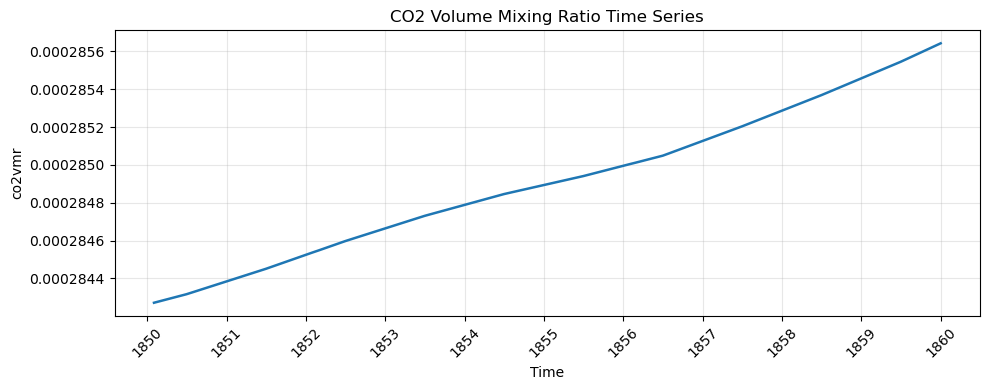

In [5]:
co2 = ds["co2vmr"]
# convert the cftime index to a datetime index for plotting
time_dt = ds.indexes["time"].to_datetimeindex()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(time_dt, co2.values, linewidth=1.8)
ax.set_title("CO2 Volume Mixing Ratio Time Series")
ax.set_xlabel("Time")
ax.set_ylabel("co2vmr")
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()


---

## Summary

fsspec combined with xarray lets you open a remote NetCDF file directly over HTTPS and read only the data you need, without storing the file locally.

### What's next?

See `globus_intro.ipynb` to transfer files to an HPC system via Globus instead of HTTP access.

## Resources and References

- [GDEX API Documentation](https://gdex.ucar.edu/api/documentation/)
- [fsspec documentation](https://filesystem-spec.readthedocs.io)